In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadumer7804/covid-19-dataset/covid_19_clean_complete.csv
/kaggle/input/datasets/muhammadumer7804/covid-19-dataset/country_wise_latest.csv
/kaggle/input/datasets/muhammadumer7804/covid-19-dataset/worldometer_data.csv


# **Step 1: Import Libraries**

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set default plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


# **Step 2: Load Data**

In [3]:
# Load All Three Datasets

path = '/kaggle/input/datasets/muhammadumer7804/covid-19-dataset/'

# time series data
df_complete = pd.read_csv(path + 'covid_19_clean_complete.csv')

# country wise latest data
df_country = pd.read_csv(path + 'country_wise_latest.csv')

# world summary data
df_world = pd.read_csv(path + 'worldometer_data.csv')

print('All datasets loaded!')
print()
print('covid_19_clean_complete :', df_complete.shape)
print('country_wise_latest     :', df_country.shape)
print('worldometer_data        :', df_world.shape)

All datasets loaded!

covid_19_clean_complete : (49068, 10)
country_wise_latest     : (187, 15)
worldometer_data        : (209, 16)


# **Step 3: First Look**

In [4]:
#  First Look at All Datasets

print('=== COVID Complete Dataset ===')
print(df_complete.head())
print()
print('Columns:', df_complete.columns.tolist())
print()
print('=== Country Wise Latest ===')
print(df_country.head())
print()
print('=== Worldometer Data ===')
print(df_world.head())

=== COVID Complete Dataset ===
  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  

Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

=== Country Wise Latest ===
  Country/R

# **Step 4: Check Missing Values**

In [5]:
# Check Missing Values

print('=== covid_19_clean_complete ===')
print(df_complete.isnull().sum())

print()
print('=== country_wise_latest ===')
print(df_country.isnull().sum())

print()
print('=== worldometer_data ===')
print(df_world.isnull().sum())

=== covid_19_clean_complete ===
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

=== country_wise_latest ===
Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

=== worldometer_data ===
Country/Region        0
Continent             1
Population            1
TotalCases            0
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases

# **Step 5: Handle Missing Values**

In [6]:
#Handle Missing Values

# covid_19_clean_complete
# Province/State — not needed, drop this column
df_complete.drop(columns=['Province/State'], inplace=True)

# worldometer_data
# NewCases, NewDeaths, NewRecovered — almost all missing, drop these columns
df_world.drop(columns=['NewCases', 'NewDeaths', 'NewRecovered'], inplace=True)

# fill remaining missing values with 0
df_world.fillna(0, inplace=True)

print('Missing values handled!')
print()
print('df_complete missing:', df_complete.isnull().sum().sum())
print('df_country missing :', df_country.isnull().sum().sum())
print('df_world missing   :', df_world.isnull().sum().sum())

Missing values handled!

df_complete missing: 0
df_country missing : 0
df_world missing   : 0


# **Step 6: Fix Data Types**

In [7]:
# Fix Data Types
# Date column is object, convert to datetime

df_complete['Date'] = pd.to_datetime(df_complete['Date'])

print('Data types fixed!')
print()
print('Date column type:', df_complete['Date'].dtype)
print()
print('Date range:')
print('From:', df_complete['Date'].min())
print('To  :', df_complete['Date'].max())

Data types fixed!

Date column type: datetime64[ns]

Date range:
From: 2020-01-22 00:00:00
To  : 2020-07-27 00:00:00


# **Step 7: Check Duplicates**

In [8]:
# Check Duplicates

print('df_complete duplicates:', df_complete.duplicated().sum())
print('df_country duplicates :', df_country.duplicated().sum())
print('df_world duplicates   :', df_world.duplicated().sum())

# remove if any
df_complete.drop_duplicates(inplace=True)
df_country.drop_duplicates(inplace=True)
df_world.drop_duplicates(inplace=True)

print()
print('Duplicates removed!')

df_complete duplicates: 0
df_country duplicates : 0
df_world duplicates   : 0

Duplicates removed!


# **Step 8: Data Cleaning Summary**

In [9]:
# Data Cleaning Summary

print('Data Cleaning Complete!')
print()
print('df_complete:')
print('  Shape          :', df_complete.shape)
print('  Date range     : Jan 2020 to Jul 2020')
print('  Countries      :', df_complete['Country/Region'].nunique())
print()
print('df_country:')
print('  Shape          :', df_country.shape)
print('  Total confirmed:', df_country['Confirmed'].sum())
print('  Total deaths   :', df_country['Deaths'].sum())
print()
print('df_world:')
print('  Shape          :', df_world.shape)
print('  Total cases    :', df_world['TotalCases'].sum())
print('  Total deaths   :', df_world['TotalDeaths'].sum())

Data Cleaning Complete!

df_complete:
  Shape          : (49068, 9)
  Date range     : Jan 2020 to Jul 2020
  Countries      : 187

df_country:
  Shape          : (187, 15)
  Total confirmed: 16480485
  Total deaths   : 654036

df_world:
  Shape          : (209, 13)
  Total cases    : 19169166
  Total deaths   : 713007.0


# **Chart 1: Global Cases Over Time**

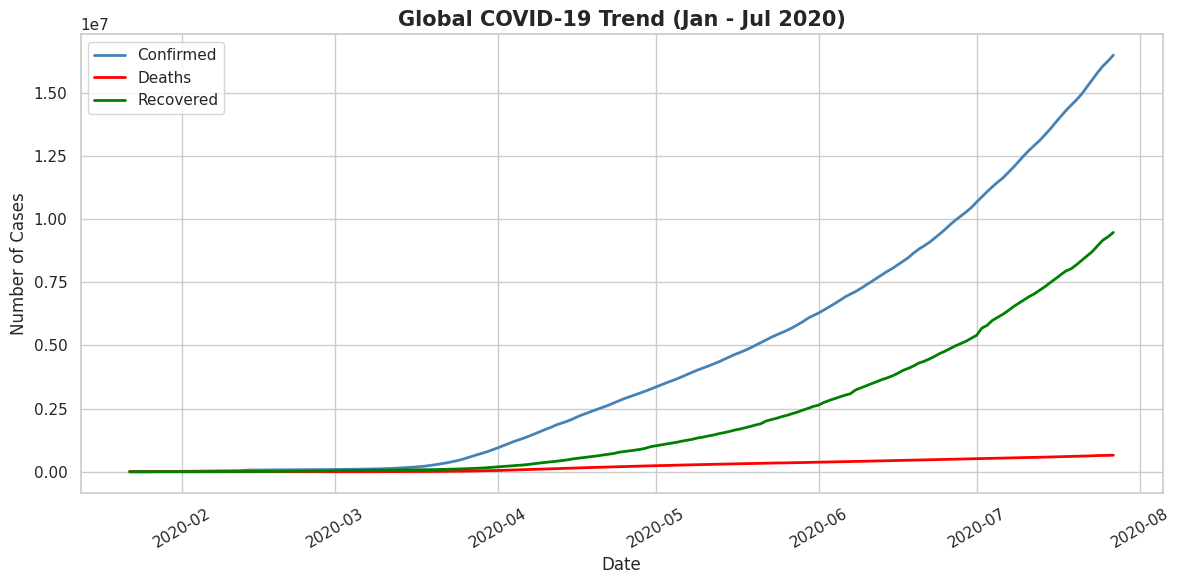

In [10]:
# Global COVID Cases Over Time

global_trend = df_complete.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(global_trend['Date'], global_trend['Confirmed'],
         color='steelblue', linewidth=2, label='Confirmed')
plt.plot(global_trend['Date'], global_trend['Deaths'],
         color='red', linewidth=2, label='Deaths')
plt.plot(global_trend['Date'], global_trend['Recovered'],
         color='green', linewidth=2, label='Recovered')

plt.title('Global COVID-19 Trend (Jan - Jul 2020)',
          fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# Summary

latest = global_trend.iloc[-1]

print('Global COVID-19 Summary (as of July 2020)')
print()
print('Total Confirmed :', f"{int(latest['Confirmed']):,}")
print('Total Deaths    :', f"{int(latest['Deaths']):,}")
print('Total Recovered :', f"{int(latest['Recovered']):,}")
print()
death_rate = round(latest['Deaths'] / latest['Confirmed'] * 100, 2)
recovery_rate = round(latest['Recovered'] / latest['Confirmed'] * 100, 2)
print('Death Rate      :', death_rate, '%')
print('Recovery Rate   :', recovery_rate, '%')

Global COVID-19 Summary (as of July 2020)

Total Confirmed : 16,480,485
Total Deaths    : 654,036
Total Recovered : 9,468,087

Death Rate      : 3.97 %
Recovery Rate   : 57.45 %


# **Chart 2: Top 10 Countries by Cases**

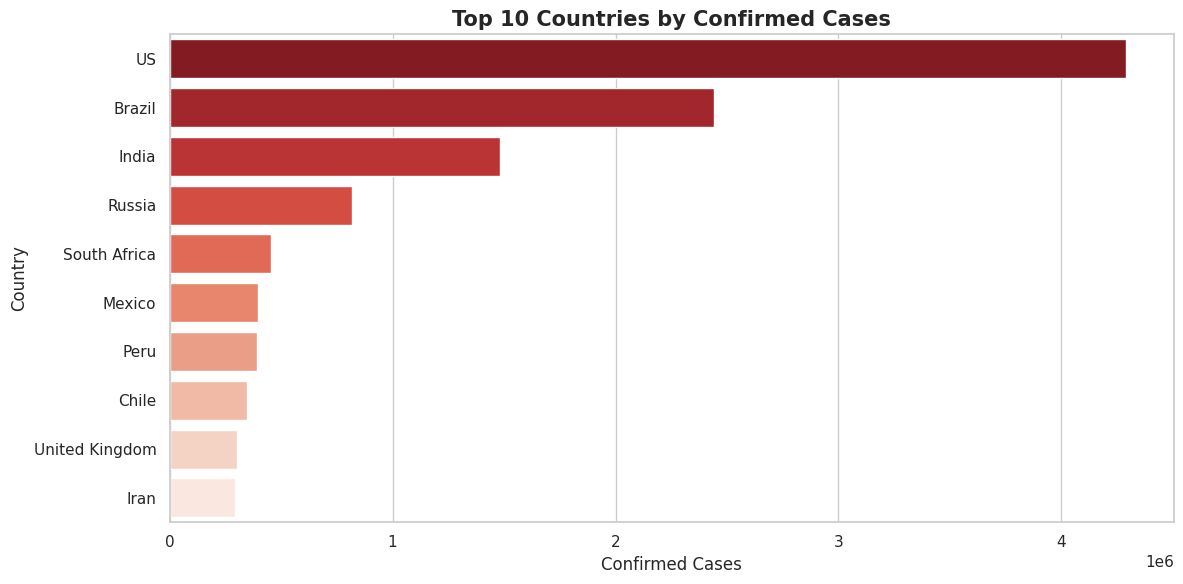

Top 5 countries by confirmed cases:
US : 4,290,259 cases
Brazil : 2,442,375 cases
India : 1,480,073 cases
Russia : 816,680 cases
South Africa : 452,529 cases


In [12]:
# Top 10 Countries by Confirmed Cases

top_countries = df_country.nlargest(10, 'Confirmed')[['Country/Region', 'Confirmed', 'Deaths']]
top_countries.columns = ['Country', 'Confirmed', 'Deaths']

plt.figure(figsize=(12, 6))

sns.barplot(data=top_countries, x='Confirmed', y='Country', palette='Reds_r')

plt.title('Top 10 Countries by Confirmed Cases',
          fontsize=15, fontweight='bold')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# summary
print('Top 5 countries by confirmed cases:')
for i, row in top_countries.head().iterrows():
    print(f"{row['Country']} : {row['Confirmed']:,} cases")

# **Chart 3: Death Rate by WHO Region**

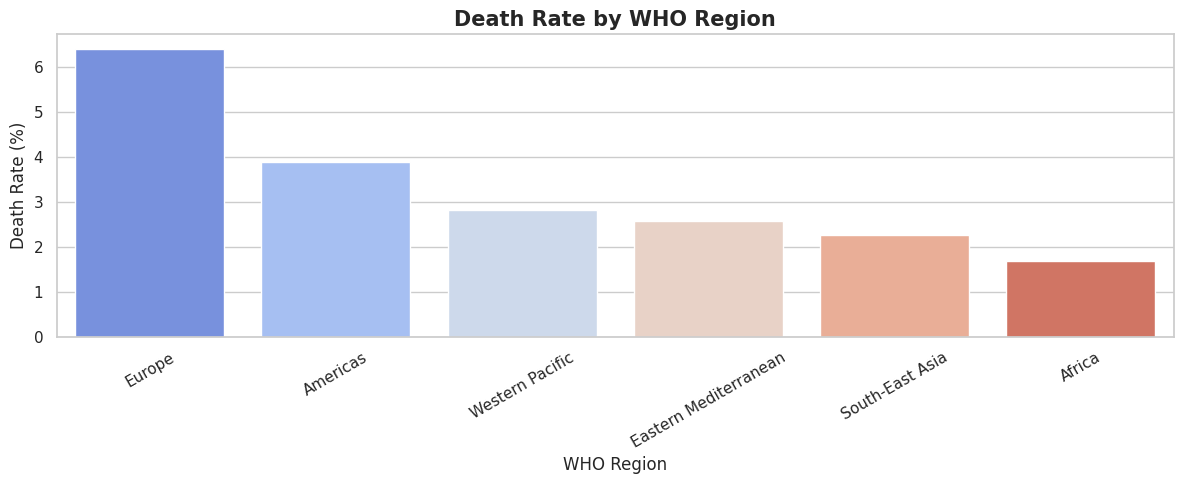

Death Rate by WHO Region:
Europe : 6.4%
Americas : 3.88%
Western Pacific : 2.82%
Eastern Mediterranean : 2.57%
South-East Asia : 2.25%
Africa : 1.69%


In [13]:
# Death Rate by WHO Region

region_data = df_country.groupby('WHO Region')[['Confirmed', 'Deaths']].sum().reset_index()
region_data['Death Rate'] = (region_data['Deaths'] / region_data['Confirmed'] * 100).round(2)
region_data = region_data.sort_values('Death Rate', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(data=region_data, x='WHO Region', y='Death Rate', palette='coolwarm')

plt.title('Death Rate by WHO Region',
          fontsize=15, fontweight='bold')
plt.xlabel('WHO Region')
plt.ylabel('Death Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# summary
print('Death Rate by WHO Region:')
for i, row in region_data.iterrows():
    print(f"{row['WHO Region']} : {row['Death Rate']}%")

# **Chart 4: Top 10 Countries by Death Rate**

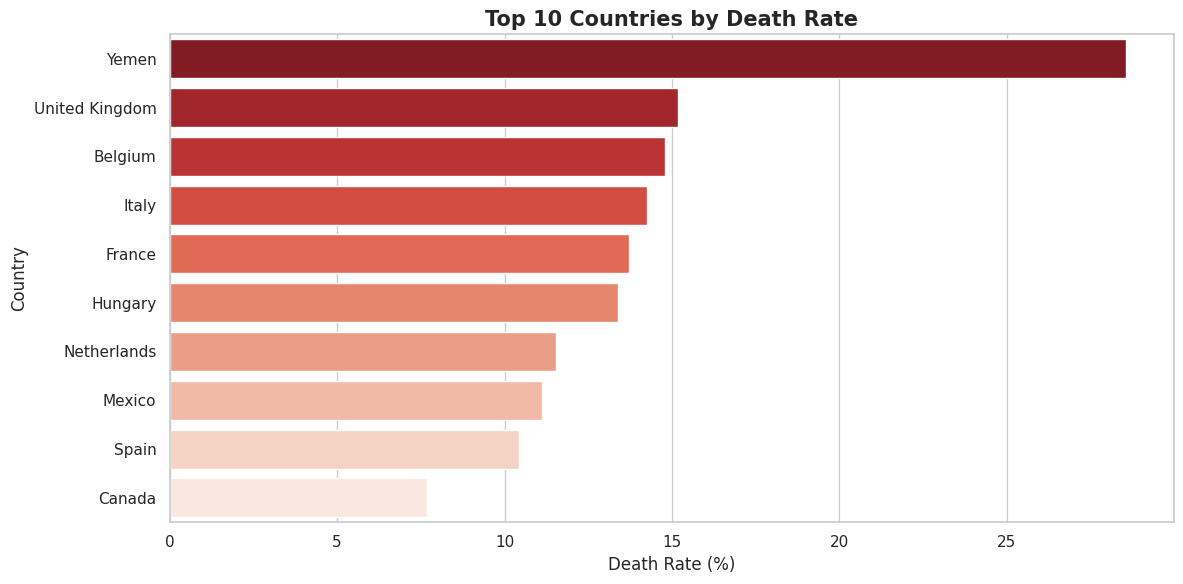

Top 5 countries by death rate:
Yemen : 28.56%
United Kingdom : 15.19%
Belgium : 14.79%
Italy : 14.26%
France : 13.71%


In [14]:
# Top 10 Countries by Death Rate

df_country['Death Rate'] = (df_country['Deaths'] / df_country['Confirmed'] * 100).round(2)

top_death = df_country[df_country['Confirmed'] > 1000]
top_death = top_death.nlargest(10, 'Death Rate')[['Country/Region', 'Death Rate', 'Confirmed']]
top_death.columns = ['Country', 'Death Rate', 'Confirmed']

plt.figure(figsize=(12, 6))

sns.barplot(data=top_death, x='Death Rate', y='Country', palette='Reds_r')

plt.title('Top 10 Countries by Death Rate',
          fontsize=15, fontweight='bold')
plt.xlabel('Death Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# summary
print('Top 5 countries by death rate:')
for i, row in top_death.head().iterrows():
    print(f"{row['Country']} : {row['Death Rate']}%")

# **Chart 5: Recovery Rate Top 10 Countries**

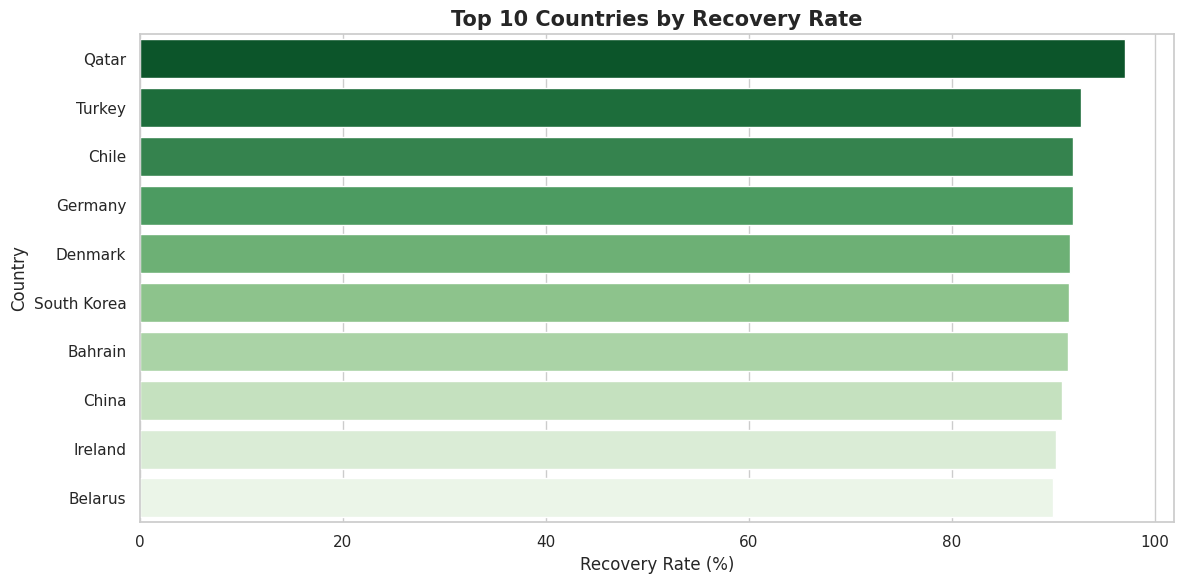

Top 5 countries by recovery rate:
Qatar : 97.02%
Turkey : 92.71%
Chile : 91.96%
Germany : 91.89%
Denmark : 91.6%


In [15]:
# Top 10 Countries by Recovery Rate

df_country['Recovery Rate'] = (df_country['Recovered'] / df_country['Confirmed'] * 100).round(2)

top_recovery = df_country[df_country['Confirmed'] > 10000]
top_recovery = top_recovery.nlargest(10, 'Recovery Rate')[['Country/Region', 'Recovery Rate']]
top_recovery.columns = ['Country', 'Recovery Rate']

plt.figure(figsize=(12, 6))

sns.barplot(data=top_recovery, x='Recovery Rate', y='Country', palette='Greens_r')

plt.title('Top 10 Countries by Recovery Rate',
          fontsize=15, fontweight='bold')
plt.xlabel('Recovery Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# summary
print('Top 5 countries by recovery rate:')
for i, row in top_recovery.head().iterrows():
    print(f"{row['Country']} : {row['Recovery Rate']}%")

# **Final Summary**

In [16]:
# Final Summary

print('COVID-19 Global Analysis Complete!')
print()
print('Dataset Summary:')
print('Total countries  :', df_country.shape[0])
print('Date range       : Jan 2020 to Jul 2020')
print()
print('Global Numbers:')
print('Total confirmed  :', f"{df_country['Confirmed'].sum():,}")
print('Total deaths     :', f"{df_country['Deaths'].sum():,}")
print('Total recovered  :', f"{df_country['Recovered'].sum():,}")
print()
print('Key Findings:')
print('Most cases       : USA — 4,290,259')
print('Highest death rate: Yemen — 28.56%')
print('Best recovery    : Qatar — 97.02%')
print('Worst region     : Europe — 6.4% death rate')
print('Best region      : Africa — 1.69% death rate')

COVID-19 Global Analysis Complete!

Dataset Summary:
Total countries  : 187
Date range       : Jan 2020 to Jul 2020

Global Numbers:
Total confirmed  : 16,480,485
Total deaths     : 654,036
Total recovered  : 9,468,087

Key Findings:
Most cases       : USA — 4,290,259
Highest death rate: Yemen — 28.56%
Best recovery    : Qatar — 97.02%
Worst region     : Europe — 6.4% death rate
Best region      : Africa — 1.69% death rate
